In [1]:
import config
config.configure_global_paths()
from model.ts2vec.ts2vec import TS2Vec_Learner
import numpy as np
import torch
from utils.utils import create_windows, normalise, score_windows
from model.ts2vec.utils import create_ts2vec_dataset
import matplotlib.pyplot as plt
from utils.metrics import all_metrics
from model.M_mahala.movingmahala import MovingMahalanobis
from utils.utils import flatten_data
from tqdm import tqdm

In [3]:
model = TS2Vec_Learner(
        input_dims=1,
        output_dims=12,
        train_data = np.random.randn(1,1,1),
        device="cpu",
    )
model.net.load_state_dict(torch.load('/home/onyxia/work/moving_mahalanobis/model/ts2vec/model_weights.pth',
                                     map_location=torch.device('cpu')))

/tmp/ipykernel_15514/3377116783.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.net.load_state_dict(torch.load('/home/onyxia/work/moving_mahalanobis/model/ts2vec/m

<All keys matched successfully>

In [4]:
import json
with open("/home/onyxia/work/moving_mahalanobis/data/KPI_anomaly/kpi.json", "r") as file:
    data = json.load(file)

In [5]:
data_kpi = flatten_data(data)

In [10]:
key = list(data_kpi.keys())[2]

In [11]:
import pandas as pd
seq_len = 32
path_to_file = "/home/onyxia/work/moving_mahalanobis/data/NAB_anomaly/ec2_cpu_utilization_ac20cd.csv"
df = pd.read_csv(path_to_file)
X = df["value"].to_numpy()
y = df["label"].to_numpy()
X = data_kpi[key]["X"][:10000]
y = data_kpi[key]["y"][:10000]
y = create_windows(y.flatten(), seq_len=seq_len, stride=seq_len)
loader = create_ts2vec_dataset(X, model, seq_len=seq_len, stride=seq_len, device="cpu")

In [12]:
mahala = MovingMahalanobis(y, loader, model_name="TS2Vec", X=X, seq_len=32)
params = {"print_results": False, "thresh":12, "mode_auto": True,
          "windows": True, "verbose": True, "n_channels" : 12,
          "seq_len": 32, "stride":32, "model_name": "TS2Vec", "device": "cpu", "modif_score": False}
mahala.set_params(**params)
out = mahala.fit()
for key in out.keys():
    print(key, ":", out[key])

100%|██████████| 312/312 [00:12<00:00, 25.91it/s]


Accuracy : 0.9966555183946488
F1 : 0.8
Precision : 1.0
Recall : 0.6666666666666666
Roc_Auc : 0.9966216216216217
AUPr : 0.8333333333333333
FPR@95% : 0.010135135135135136
n_anomaly : 3
n_data : 299
model : TS2Vec


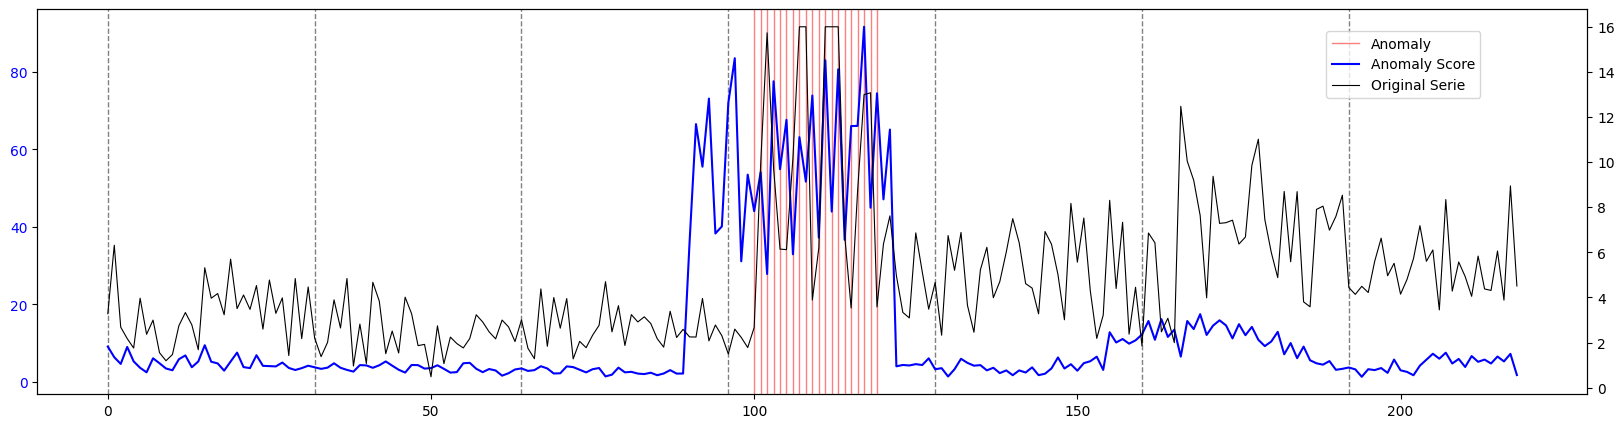

In [16]:
mahala.plot_anomalies(1)

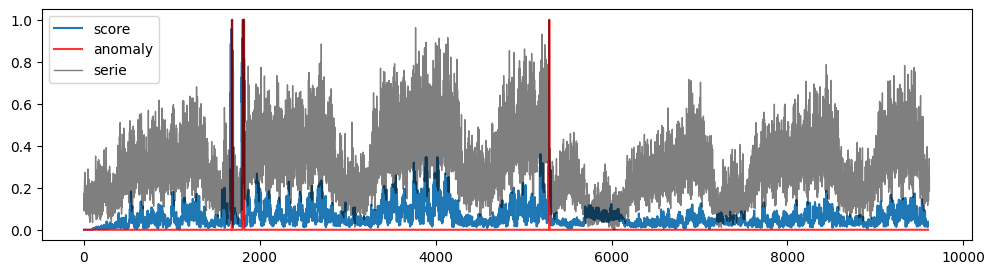

In [20]:
plt.figure(figsize=(12,3))
plt.plot(normalise(np.clip(mahala.score, None, 7000)), label="score")
plt.plot(mahala.labels, alpha=0.8, c="r", label="anomaly")
plt.plot(normalise(mahala.X.flatten()), linewidth=1, alpha=0.5, c="black", label="serie")
plt.legend()
plt.show()

Accuracy: 0.9967
F1 Score: 0.8000
Precision: 1.0000
Recall: 0.6667
AUC: 0.9966
AUPR: 0.8333
Taux de faux positifs à 95% de sensibilité : 0.0101


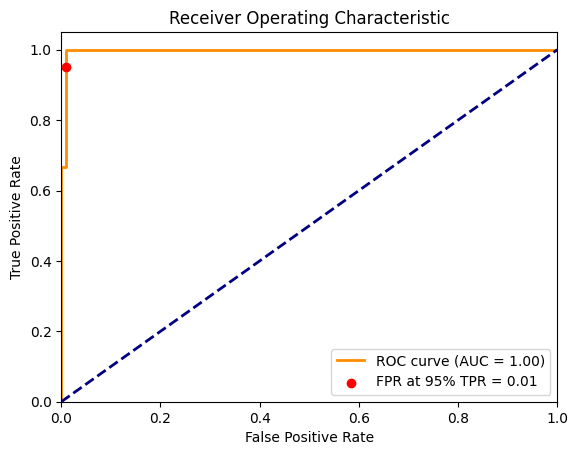

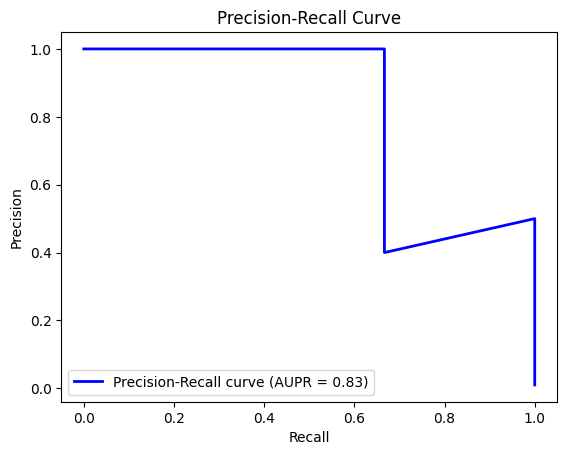

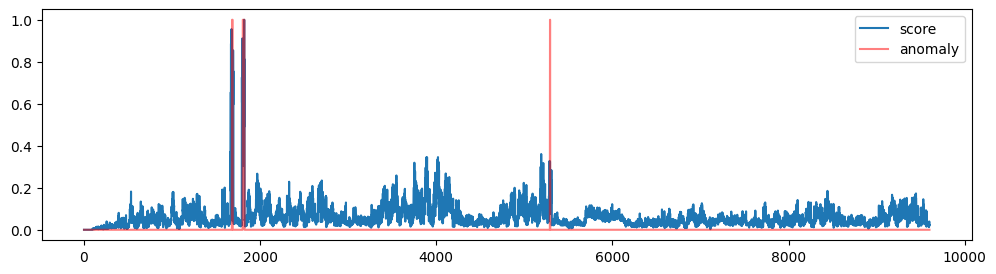

In [26]:
label_w, score_w = score_windows(mahala.labels, mahala.score, seq_len=32)
all_metrics(label_w, score_w, verbose=True)
plt.figure(figsize=(12,3))
plt.plot(normalise(np.clip(mahala.score, None, 300)), label="score")
plt.plot(mahala.labels, alpha=0.5, c="r", label="anomaly")
plt.legend()
plt.show()

In [13]:
def eval_model(learner, model, data, params, loader, save_score=False):
    """
    Évalue un modèle sur un ensemble de données donné et retourne les résultats.

    Paramètres :
    -----------
    learner : object
        L'evaluator utilisé pour entraîner et évaluer le modèle, il comprends une fonctions get_params et fit().
    
    model : object
        Le modèle (exemple TS2Vec, Lagllama), si le modèle est deja compris dans l'evaluator, rentrer None
    
    data : dict
        Dictionnaire contenant les données d'entrée. Chaque clé du dictionnaire représente un ensemble de données, 
        et la valeur est un autre dictionnaire contenant 'X' et 'y' .
    
    params : dict
        Dictionnaire de paramètres à passer à l'évaluateur et au modèle. Il doit contenir :
        - 'seq_len' : longueur des séquences de données à traiter.
        - 'device' : appareil (CPU ou GPU) sur lequel exécuter le modèle.
        - 'model_name' : nom du modèle utilisé pour l'évaluation.
        - et paramètres spécifiques à chaque modèles
    
    loader : function
        Fonction ou classe qui transforme les données d'entrée 'X' en un format approprié pour l'évaluation 
        (par exemple, un DataLoader).
    
    save_score : bool, optionnel (par défaut=False)
        Si True, les scores et les labels pour chaque ensemble de données seront enregistrés dans un dictionnaire 
        et retournés avec les résultats.
    
    Retour :
    -------
    list_res : dict
        Dictionnaire contenant les résultats de l'évaluation pour chaque clé de données.
    
    list_scores : dict
        Dictionnaire contenant les scores et les labels pour chaque clé de données, uniquement si `save_score=True`.
    """    
    list_res = {}

    list_scores = {}

    for key in tqdm(data.keys()):
        X = data[key]["X"]
        y = data[key]["y"]
        
        dataset = loader(X, model, seq_len=params["seq_len"],
                         stride=params["seq_len"], device=params["device"])
        y = create_windows(y, seq_len=params["seq_len"], stride=params["seq_len"])
        evaluator = learner(y, dataset, model_name=params["model_name"], 
                            X=X, seq_len= params["seq_len"])
        evaluator.set_params(**params)
        list_res[key] = evaluator.fit()

        if save_score:
            list_scores[key] = {"scores": evaluator.score,
                                "labels": evaluator.labels}
    
    return list_res, list_scores

In [14]:
params = {"print_results": False, "thresh":12, "mode_auto": True,
          "windows": True, "verbose": False, "n_channels" : 12,
          "seq_len": 32, "stride":32, "model_name": "TS2Vec", "device": "cuda"}
test = eval_model(MovingMahalanobis, model, data_kpi, params, create_ts2vec_dataset, save_score=True)

  0%|          | 0/29 [01:39<?, ?it/s]
